Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-panoptic...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 panoptic,
Done loading in 0.738 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.

--- Rendering camera and LiDAR images ---


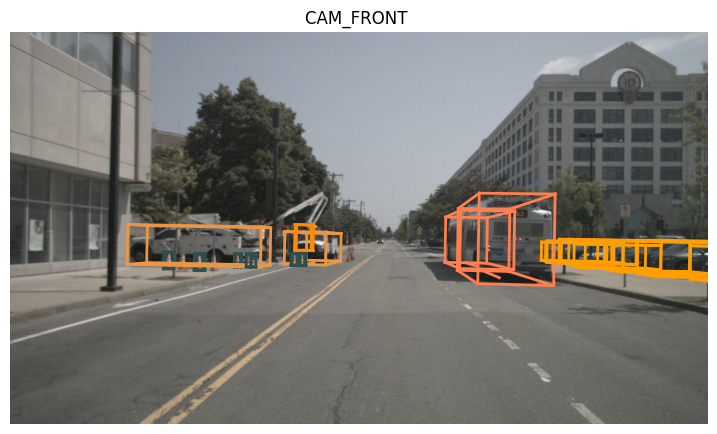

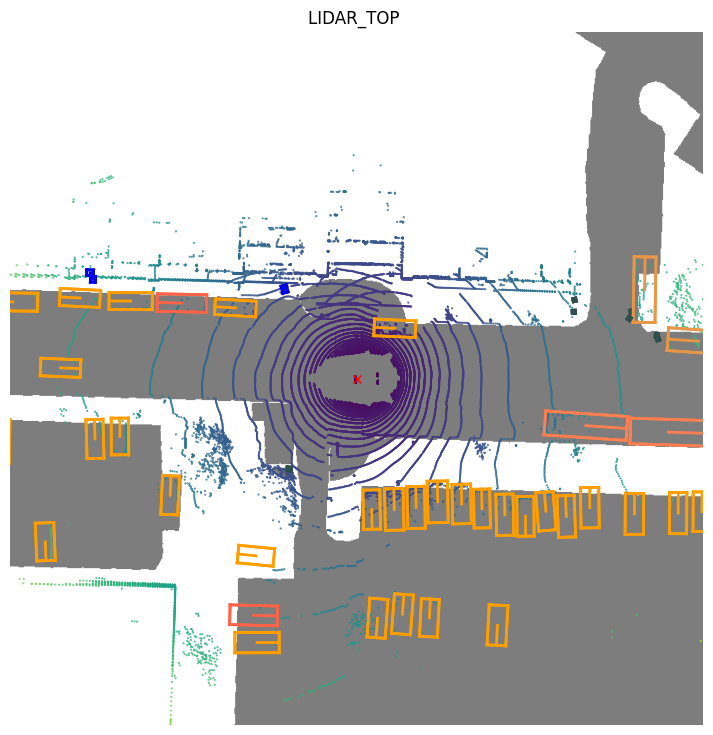


Scene: 4 (scene-0655)
Sample: 26
Token: 0402e40724984f3b833496067d46c771
Number of annotations: 66

--- Object Category Distribution ---
vehicle.car: 48 instance(s)
movable_object.trafficcone: 7 instance(s)
vehicle.truck: 3 instance(s)
human.pedestrian.adult: 3 instance(s)
vehicle.construction: 2 instance(s)
vehicle.bus.bendy: 2 instance(s)
vehicle.trailer: 1 instance(s)

Data balance check:
⚠️ Unbalanced. Max: 48, Min: 1

--- Object TTC Analysis (sorted by distance to ego) ---
 1. Object: vehicle.car                    | Distance: 7.32 m | Rel. Velocity: 7.26 m/s | TTC: 1.01 s | Attribute: vehicle.parked
 2. Object: movable_object.trafficcone     | Distance: 13.04 m | Rel. Velocity: 7.26 m/s | TTC: 1.79 s | Attribute: None
 3. Object: human.pedestrian.adult         | Distance: 13.29 m | Rel. Velocity: 7.26 m/s | TTC: 1.83 s | Attribute: pedestrian.moving
 4. Object: vehicle.car                    | Distance: 15.28 m | Rel. Velocity: 7.26 m/s | TTC: 2.10 s | Attribute: vehicle.parked


In [2]:
from nuscenes.nuscenes import NuScenes
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# === Load NuScenes dataset ===
nusc = NuScenes(version='v1.0-mini', dataroot='/data/sets/nuscenes', verbose=True)

# === PARAMETERS ===
scene_index = 3
sample_index = 25
camera_channel = 'CAM_FRONT'
lidar_channel = 'LIDAR_TOP'

# === GET THE SCENE AND SAMPLE ===
scene = nusc.scene[scene_index]
sample_token = scene['first_sample_token']
for _ in range(sample_index):
    sample = nusc.get('sample', sample_token)
    if not sample['next']:
        raise ValueError(f"Scene {scene_index} has fewer than {sample_index + 1} samples.")
    sample_token = sample['next']
sample = nusc.get('sample', sample_token)

# === RENDER IMAGES ===
print("\n--- Rendering camera and LiDAR images ---")
nusc.render_sample_data(sample['data'][camera_channel], with_anns=True)
nusc.render_sample_data(sample['data'][lidar_channel], with_anns=True)

# === Scene Info ===
print(f"\nScene: {scene_index + 1} ({scene['name']})")
print(f"Sample: {sample_index + 1}")
print(f"Token: {sample['token']}")
print(f"Number of annotations: {len(sample['anns'])}")

# === Object Category Distribution ===
category_counter = Counter()
for ann_token in sample['anns']:
    ann = nusc.get('sample_annotation', ann_token)
    category_counter[ann['category_name']] += 1
print("\n--- Object Category Distribution ---")
for category, count in category_counter.most_common():
    print(f"{category}: {count} instance(s)")

# === Balance Check ===
if category_counter:
    max_count = max(category_counter.values())
    min_count = min(category_counter.values())
    print("\nData balance check:")
    if max_count - min_count <= 2:
        print(f"✅ Balanced. Max: {max_count}, Min: {min_count}")
    else:
        print(f"⚠️ Unbalanced. Max: {max_count}, Min: {min_count}")
else:
    print("No annotations available to check balance.")

# === Ego Pose and Velocity ===
lidar_token = sample['data'][lidar_channel]
lidar_data = nusc.get('sample_data', lidar_token)
ego_pose = nusc.get('ego_pose', lidar_data['ego_pose_token'])
ego_translation = np.array(ego_pose['translation'])
ego_velocity = np.array([0.0, 0.0, 0.0])
if lidar_data['prev']:
    prev_lidar_data = nusc.get('sample_data', lidar_data['prev'])
    prev_pose = nusc.get('ego_pose', prev_lidar_data['ego_pose_token'])
    dt = (lidar_data['timestamp'] - prev_lidar_data['timestamp']) * 1e-6
    if dt > 0:
        ego_velocity = (np.array(ego_pose['translation']) - np.array(prev_pose['translation'])) / dt

# === Instance Velocity Function ===
def get_instance_velocity(nusc, instance_token, current_ann_token):
    try:
        instance = nusc.get('instance', instance_token)
        annotations = instance.get('anns', [])
        if current_ann_token not in annotations:
            return np.array([0.0, 0.0, 0.0])
        curr_idx = annotations.index(current_ann_token)
        if curr_idx == 0:
            return np.array([0.0, 0.0, 0.0])
        prev_ann_token = annotations[curr_idx - 1]
        curr_ann = nusc.get('sample_annotation', current_ann_token)
        prev_ann = nusc.get('sample_annotation', prev_ann_token)
        t1 = np.array(prev_ann['translation'])
        t2 = np.array(curr_ann['translation'])
        dt = (curr_ann['timestamp'] - prev_ann['timestamp']) * 1e-6
        if dt == 0:
            return np.array([0.0, 0.0, 0.0])
        return (t2 - t1) / dt
    except Exception as e:
        print(f"Error getting velocity for instance {instance_token}: {e}")
        return np.array([0.0, 0.0, 0.0])

# === Time-To-Collision (TTC) Analysis ===
print("\n--- Object TTC Analysis (sorted by distance to ego) ---")

ttc_results = []
for ann_token in sample['anns']:
    annotation = nusc.get('sample_annotation', ann_token)
    object_translation = np.array(annotation['translation'])
    distance = np.linalg.norm(object_translation - ego_translation)

    instance_token = annotation.get('instance_token')
    if not instance_token:
        continue

    category_name = annotation['category_name']
    attribute_token = annotation['attribute_tokens'][0] if annotation['attribute_tokens'] else None
    attribute = nusc.get('attribute', attribute_token)['name'] if attribute_token else "None"

    object_velocity = get_instance_velocity(nusc, instance_token, ann_token)
    rel_velocity = np.linalg.norm(object_velocity - ego_velocity)
    ttc = distance / rel_velocity if rel_velocity > 0 else float('inf')

    ttc_results.append({
        'distance': distance,
        'ttc': ttc,
        'category': category_name,
        'attribute': attribute,
        'rel_velocity': rel_velocity
    })

# Sort TTC results by distance
ttc_results.sort(key=lambda x: x['distance'])

# Print results sorted by distance
for i, result in enumerate(ttc_results):
    print(f"{i+1:2d}. Object: {result['category']:30s} | "
          f"Distance: {result['distance']:.2f} m | "
          f"Rel. Velocity: {result['rel_velocity']:.2f} m/s | "
          f"TTC: {result['ttc']:.2f} s | "
          f"Attribute: {result['attribute']}")

# === Highlight the Two Closest Objects Separately ===
print("\n=== 🔍 CLOSEST OBJECTS SUMMARY ===")
for i in range(min(2, len(ttc_results))):
    obj = ttc_results[i]
    print(f"➡️ Object {i+1}: {obj['category']} | Distance = {obj['distance']:.2f} m | TTC = {obj['ttc']:.2f} s")
